### Implement Boston housing price prediction problem by Linear regression using Deep Neural network. Use Boston House price prediction dataset.

In [1]:
# Install required libraries
!pip install tensorflow scikit-learn pandas matplotlib
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

In [2]:
# Step 1: Load the dataset
import pandas as pd
# Load the dataset from a CSV file
df = pd.read_csv('Boston-house-price-data.csv')
# Display the first few rows of the dataset
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [3]:
# Step 2: Preprocess the data
from sklearn.preprocessing import StandardScaler
# Split the data into input and output variables
X = df.drop('MEDV', axis=1)
Y = df['MEDV']
# Scale the input features
scaler = StandardScaler()
X = scaler.fit_transform(X)
print(X[:5])

[[-0.41978194  0.28482986 -1.2879095  -0.27259857 -0.14421743  0.41367189
  -0.12001342  0.1402136  -0.98284286 -0.66660821 -1.45900038  0.44105193
  -1.0755623 ]
 [-0.41733926 -0.48772236 -0.59338101 -0.27259857 -0.74026221  0.19427445
   0.36716642  0.55715988 -0.8678825  -0.98732948 -0.30309415  0.44105193
  -0.49243937]
 [-0.41734159 -0.48772236 -0.59338101 -0.27259857 -0.74026221  1.28271368
  -0.26581176  0.55715988 -0.8678825  -0.98732948 -0.30309415  0.39642699
  -1.2087274 ]
 [-0.41675042 -0.48772236 -1.30687771 -0.27259857 -0.83528384  1.01630251
  -0.80988851  1.07773662 -0.75292215 -1.10611514  0.1130321   0.41616284
  -1.36151682]
 [-0.41248185 -0.48772236 -1.30687771 -0.27259857 -0.83528384  1.22857665
  -0.51117971  1.07773662 -0.75292215 -1.10611514  0.1130321   0.44105193
  -1.02650148]]


In [4]:
# Step 3: Split the dataset
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
X, Y, test_size=0.3, random_state=42
)
# Print the shapes of the training and testing sets
print('Training set shape:', X_train.shape, y_train.shape)
print('Testing set shape:', X_test.shape, y_test.shape)

Training set shape: (354, 13) (354,)
Testing set shape: (152, 13) (152,)


In [5]:
# Step 4: Define the model architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
# Define the model architecture
model = Sequential()
model.add(Dense(64, input_dim=13, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))
# Display the model summary
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

None


In [6]:
# Step 5: Compile the model
model.compile(
loss='mean_squared_error',
optimizer='adam',
metrics=['mean_absolute_error']
)

In [7]:
# Step 6: Train the model
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=5)
historyvariable = model.fit(
X_train, y_train,
validation_split=0.2,
epochs=100,
batch_size=32,
callbacks=[early_stopping]
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 610.4096 - mean_absolute_error: 22.7647 - val_loss: 557.1812 - val_mean_absolute_error: 22.1101
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 584.8199 - mean_absolute_error: 22.2162 - val_loss: 531.3217 - val_mean_absolute_error: 21.5633
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 559.1814 - mean_absolute_error: 21.6716 - val_loss: 503.1635 - val_mean_absolute_error: 20.9519
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 524.4382 - mean_absolute_error: 20.9514 - val_loss: 469.5003 - val_mean_absolute_error: 20.2052
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 484.9081 - mean_absolute_error: 20.0430 - val_loss: 428.5738 - val_mean_absolute_error: 19.2593
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 438.3631 - mean_absolute_error: 18.9900 - val_loss: 379.1468 - val_mean_absolute_error: 18.0556
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 379.3256 - mean_absolut

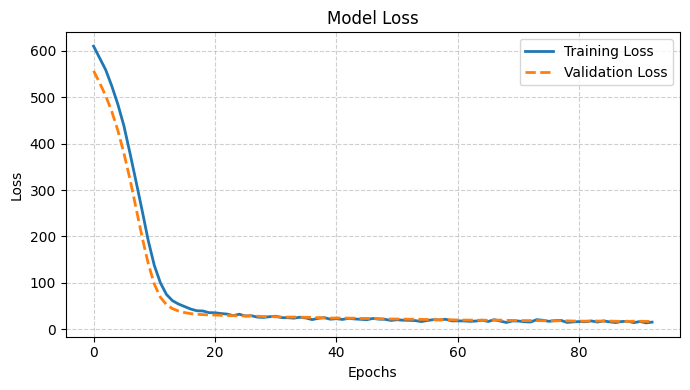

In [8]:
plt.figure(figsize=(7,4))
plt.plot(historyvariable.history['loss'],
linestyle='-', linewidth=2, label='Training Loss')
plt.plot(historyvariable.history['val_loss'],
linestyle='--', linewidth=2, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [9]:
# Step 7: Evaluate the model
# Evaluate the model on the testing set
loss, mae = model.evaluate(X_test, y_test)
# Print the mean absolute error
print('Mean Absolute Error:', mae)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13.4955 - mean_absolute_error: 2.4545
Mean Absolute Error: 2.454547882080078
